# Add in the data from the extra datasets

Make the metadata file, this we need to do by reading in each of the files and taking the first row. 

### Metadata rows.
```
experiment_id	experiment_name	experiment_date	substrate_smiles	product_smiles	assay_technique	parent_amino_acid	cif_filename

```
Since these don't have a "parent" need to think about how best to represent these...


In [88]:
import pandas as pd
import os
# First alter the files to have a parent in the first row
data_dir = 'DEDB/new-ds-yl/processed/'
files = os.listdir(data_dir)

columns = ['experiment_id', 'experiment_name', 'experiment_date', 
           'substrate_smiles', 'product_smiles', 'assay_technique', 
           'parent_amino_acid', 'cif_filename']


In [89]:
rows = []
all_df = pd.DataFrame()
for f in files:
    try:
        df = pd.read_csv(f'{data_dir}{f}')
        # Also change back the sequence to not have the mutations in it
        parent_aa = list(df['aa_sequence'].values[0])
        # Revert back the mutations
        aa_subs = df['amino_acid_substitutions'].values[0]
        for a in aa_subs.split('_'):
            pos = int(a[1:-1]) - 1 # Since usually 1 indexed
            parent_aa[pos] = a[0]
        parent_aa = ''.join(parent_aa)
    
        # Append a final row on
        plate_id = max(df['plate'].values)
        row = list(df.values[0])
        row[4] = '#PARENT#' #	1	0	0	0	0	ATGGCTGTTCCTGGTTATGATTTTGGTAAAGTTCCTGATGCTCCTATTTCTGATGCTGATTTTGAATCTCTTAAAAAAACTGTTATGTGGGGTGAAGAAGATGAAAAATATCGTAAAATGGCTTGTGAAGCTCTTAAAGGTCAAGTTGAAGATATTCTTGATCTTGCTTATGGTCTTCAAGGTTCTAATCAACATCTTATTTATTATTTTGGTGATAAATCTGGTCGTCCTATTCCTCAATATCTTGAAGCTGTTCGTAAACGTTTTGGTCTTTGGATTATTGATACTCTTTGTAAACCTCTTGATCGTCAATGGCTTAATTATATGTATGAAATTGGTCTTCGTCATCATCGTACTAAAAAAGGTAAAACTGATGGTGTTGATACTGTTGAACATATTCCTCTTCGTTATATGATTGCTTTTATTGCTCCTATTGGTCTTACTATTAAACCTATTCTTGAAAAATCTGGTCATCCTCCTGAAGCTGTTGAACGTATGTGGGCTGCTTGGGTTAAACTTGTTGTTCTTCAAGTTGCTATTTGGTCTTATCCTTATGCTAAAACTGGTGAATGG	MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALKGQVEDILDLAYGLQGSNQHLIYYFGDKSGRPIPQYLEAVRKRFGLWIIDTLCKPLDRQWLNYMYEIGLRHHRTKKGKTDGVDTVEHIPLRYMIAFIAPIGLTIKPILEKSGHPPEAVERMWAAWVKLVVLQVAIWSYPYAKTGEW	C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-]>>COC2=CC=C(C=C2)[C@@H]3[C@@H](C(OCC)=O)C3	0.679908496	selectivity: 0.066311735]
        row[13] = plate_id + 1
        row[11] = parent_aa
        row[10] = None
        row_df = pd.DataFrame([row], columns=df.columns)
        df = pd.concat([df, row_df])
        
        # Also copy accross the structure
        name = ''
        if 'PfTrpB' in f:
            name = f.replace('PfTrpB-', '').replace('_processed.csv', '')
            name = name[0] + '-' + name[1:]
            experiment_name = f'PfTrpB_{name}'
        else:
            name = f.replace('_processed.csv', '')
            experiment_name = name
        structure = f'DEDB/new-ds-yl/structure/{name}/{name}.cif'
        if os.path.exists(structure):
            os.system(f'cp {structure} DEDB/new-ds-yl/reformatted/structures/{experiment_name}.cif')
            
            rxn = df['smiles_string'].values[0]
            product = rxn.split('>>')[-1]
            substrates = rxn.split('>>')[0]
            df['smiles_string'] = product
            df['reaction_string'] = rxn
            
            row = [experiment_name, experiment_name, None, substrates, product, None,	parent_aa, f'{experiment_name}.cif']
            df.to_csv(f'DEDB/new-ds-yl/reformatted/{experiment_name}.csv', index=False)
            rows.append(row)
            all_df = pd.concat([df, all_df])
    except:
        print(f)
        
meta_df = pd.DataFrame(rows)
meta_df.columns = columns
meta_df


sample.csv


,experiment_id,experiment_name,experiment_date,substrate_smiles,product_smiles,assay_technique,parent_amino_acid,cif_filename
0,PfTrpB_7-methyl,PfTrpB_7-methyl,None,CC1=CC=CC2=C1NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=CC=C4C)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_7-methyl.cif
1,ParLQ-h,ParLQ-h,None,C=CC1=CC=C(C(F)(F)F)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(C(F)(F)F)C=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-h.cif
2,PfTrpB_5-iodo,PfTrpB_5-iodo,None,IC1=CC2=C(C=C1)NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=C(I)C=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_5-iodo.cif
3,PfTrpB_5-chloro,PfTrpB_5-chloro,None,ClC1=CC2=C(C=C1)NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=C(Cl)C=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_5-chloro.cif
4,PfTrpB_4-bromo,PfTrpB_4-bromo,None,BrC1=CC=CC2=C1C=CN2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C(Br)=CC=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_4-bromo.cif
5,PfTrpB_4-cyano,PfTrpB_4-cyano,None,N#CC1=CC=CC2=C1C=CN2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C(C#N)=CC=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_4-cyano.cif
6,ParLQ-b,ParLQ-b,None,C=CC1=CC=CC=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=CC=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-b.cif
7,PfTrpB_6-chloro,PfTrpB_6-chloro,None,ClC1=CC2=C(C=CN2)C=C1.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=CC(Cl)=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_6-chloro.cif
8,ParLQ-f,ParLQ-f,None,C=CC1=CC=C(Cl)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(Cl)C=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-f.cif
9,ParLQ-a,ParLQ-a,None,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],COC2=CC=C(C=C2)[C@@H]3[C@@H](C(OCC)=O)C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-a.cif


In [90]:
meta_df.to_csv('DEDB/new-ds-yl/reformatted/meta_data_new_collections.csv', index=False)

In [91]:
len(meta_df)

21

In [92]:
len(all_df)

7181

In [93]:
len(set(all_df['aa_sequence'].values))

883

In [94]:
len(set(all_df['reaction_string'].values))

21

In [95]:
881 - 21 + 362

1222

In [96]:
1325 + 7160

8485

In [97]:
7160 + 2468 

9628

# Draw some graphs for the reviewer to show the distribution of fitness values


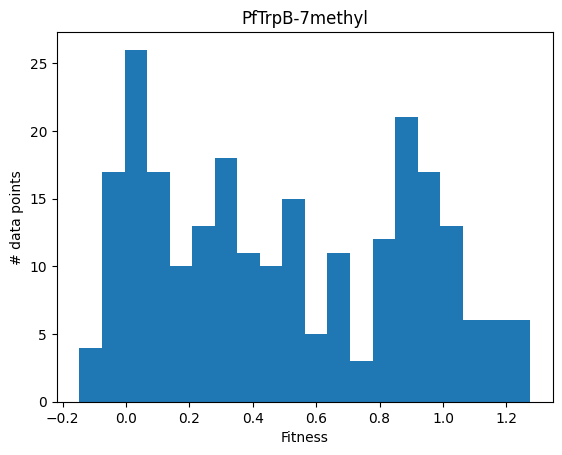

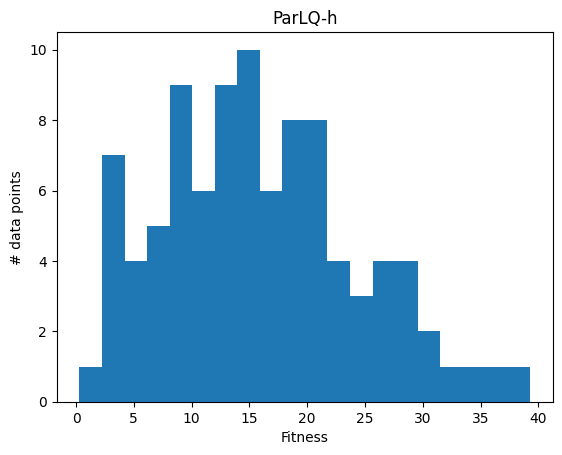

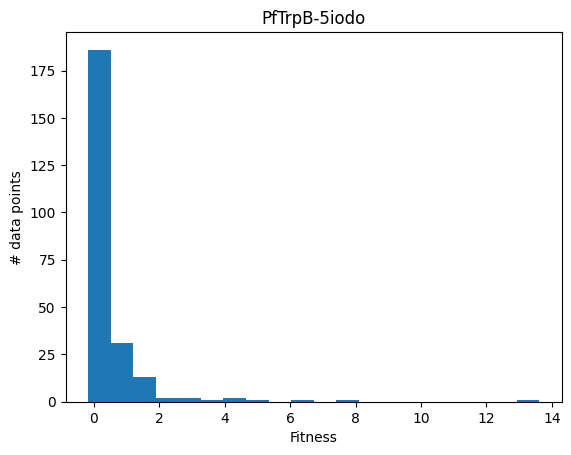

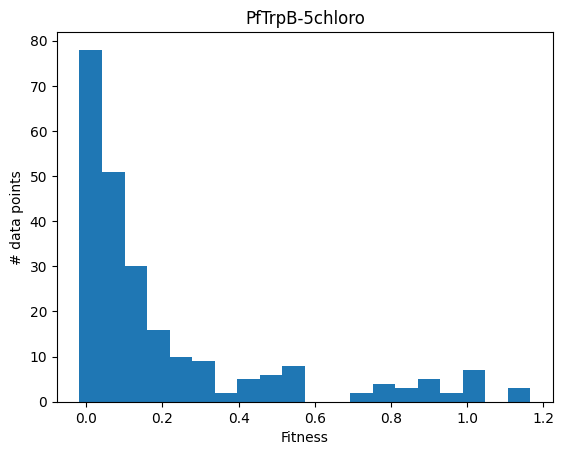

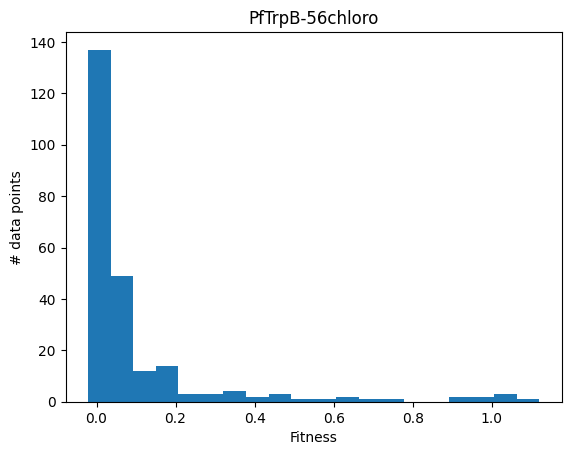

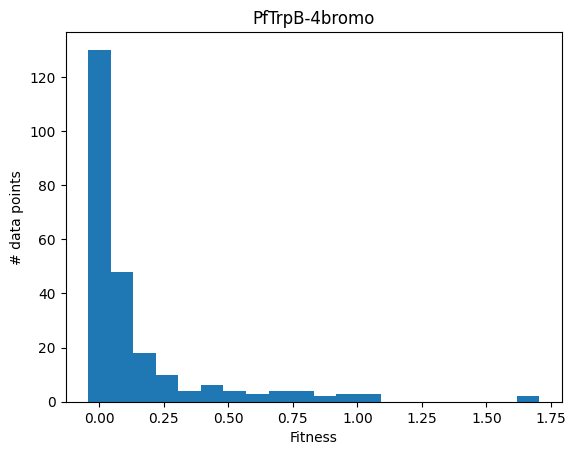

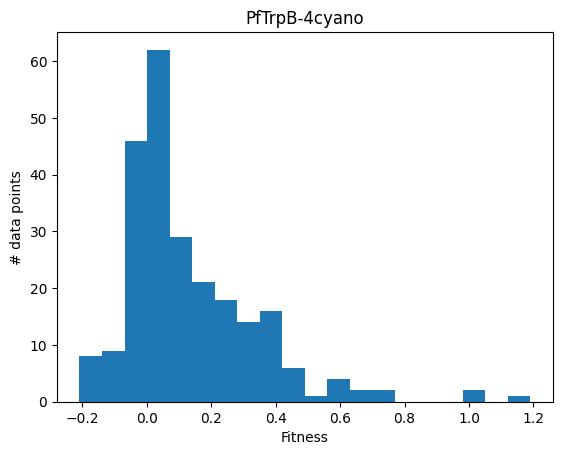

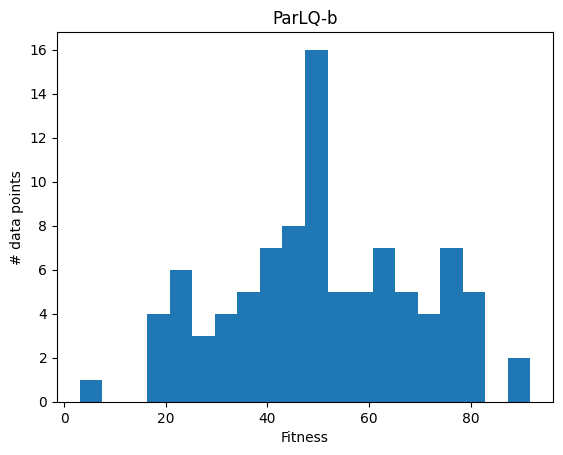

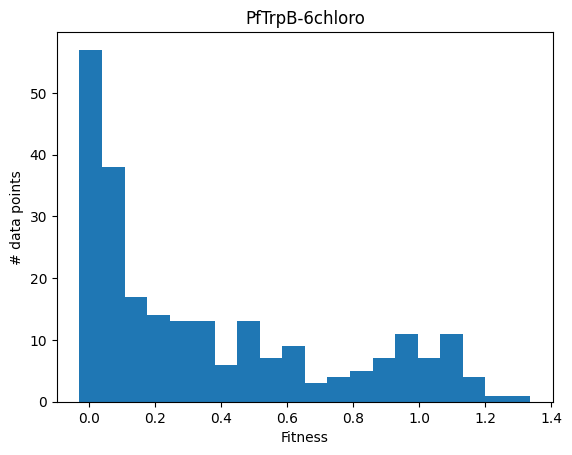

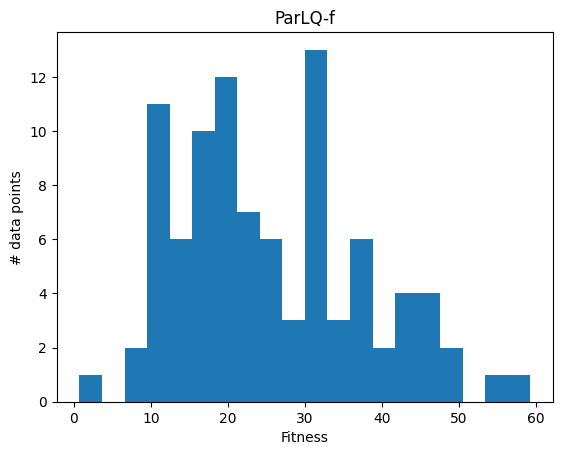

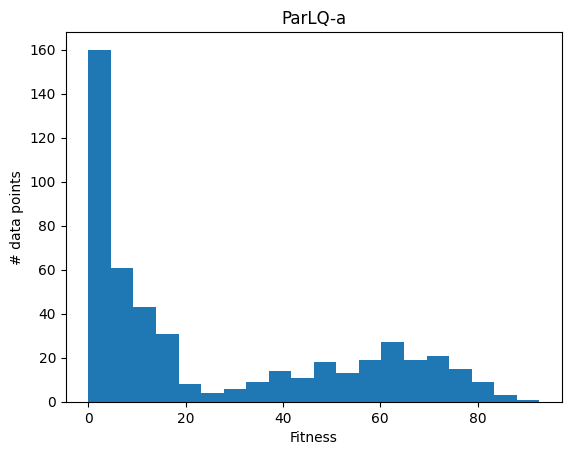

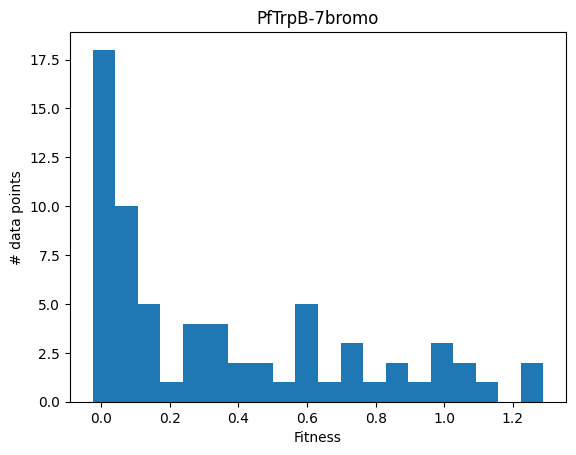

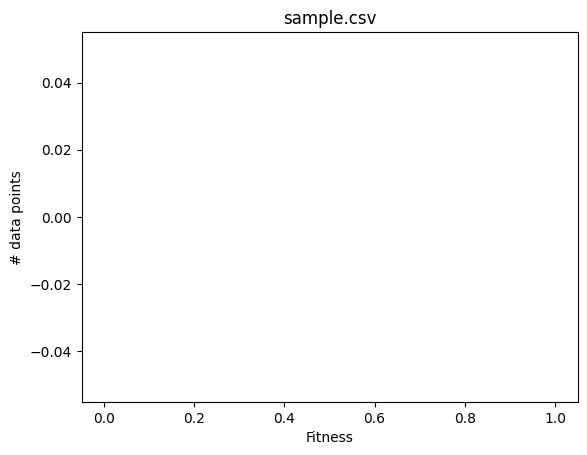

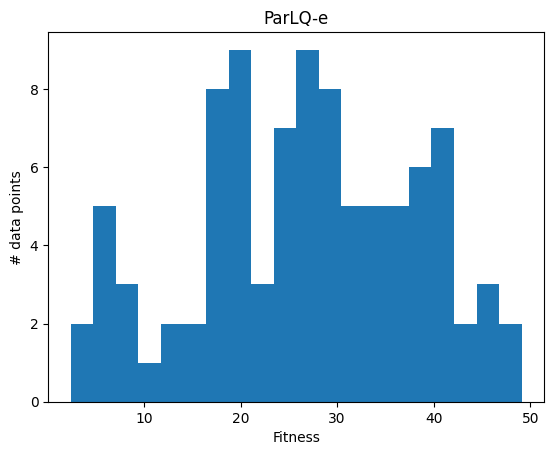

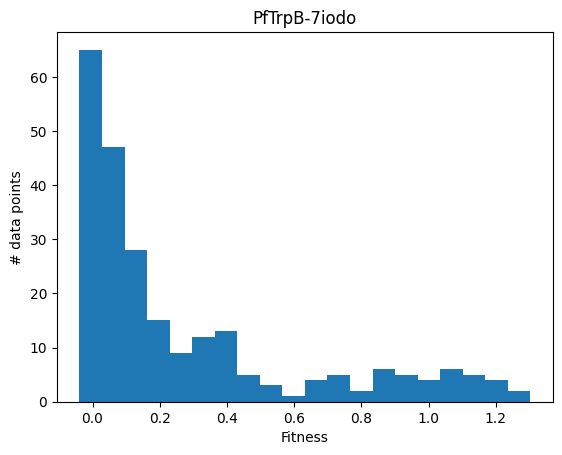

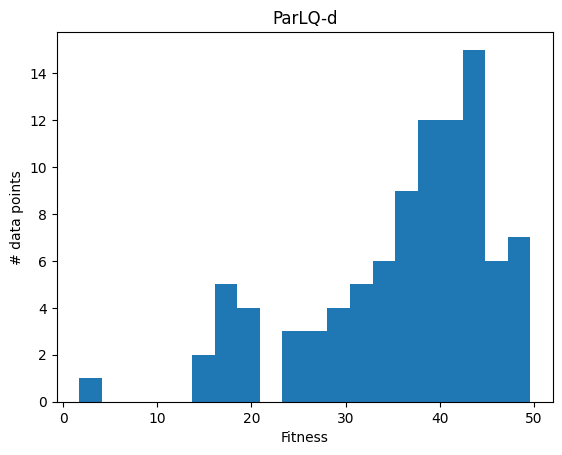

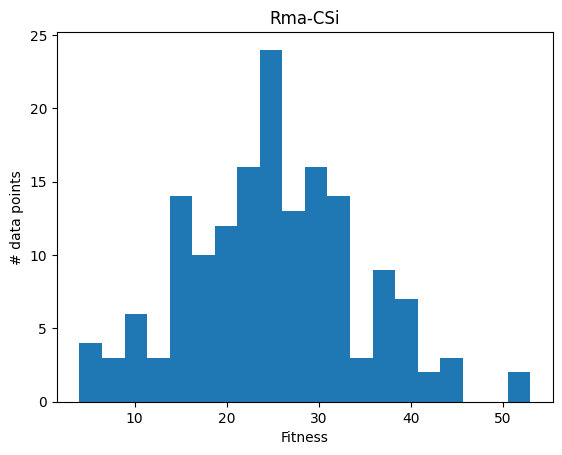

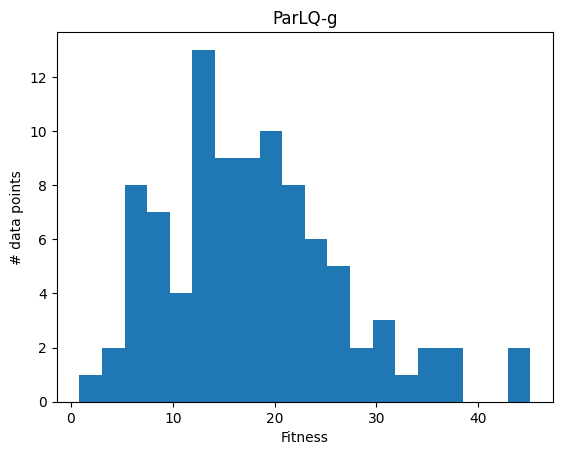

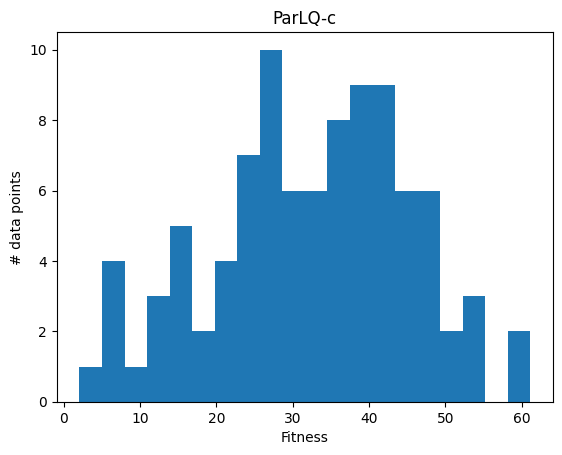

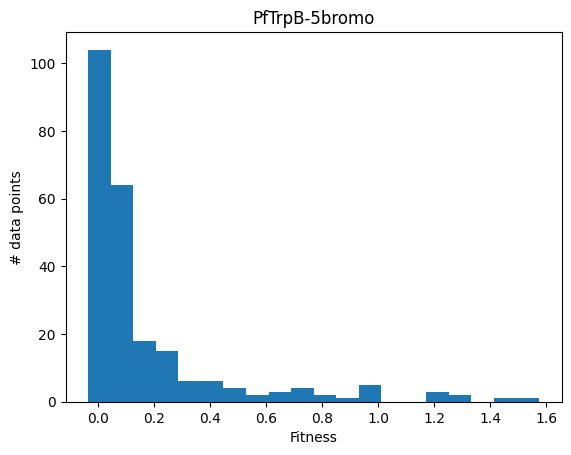

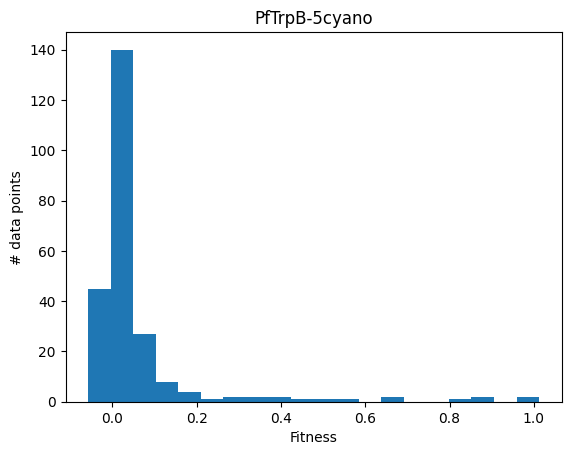

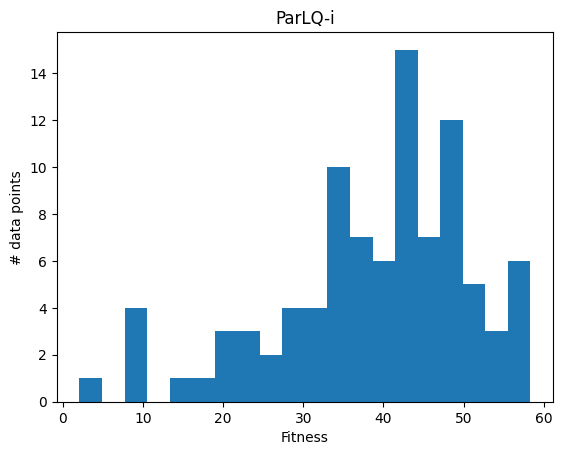

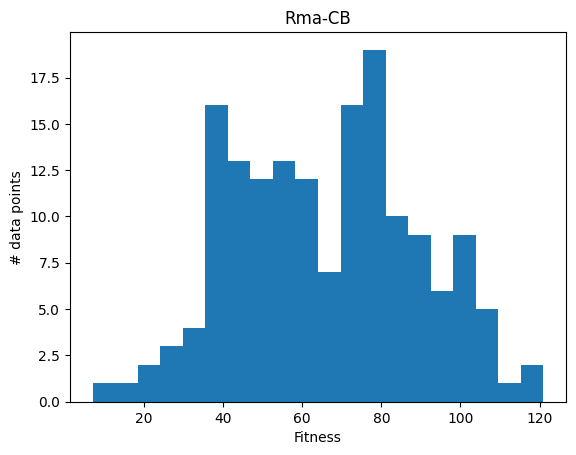

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

for f in files:
    try:
        df = pd.read_csv(f'{data_dir}{f}')
        plt.hist(df['fitness_value'].values, bins=20)
        plt.title(f.replace('_processed.csv', ''))
        plt.xlabel('Fitness')
        plt.ylabel('# data points')
        plt.show()
    except:
        print(f)


In [98]:
import pandas as pd
import os
# First alter the files to have a parent in the first row
data_dir = 'DEDB/new-ds-fzl/processed/'
files = os.listdir(data_dir)

columns = ['experiment_id', 'experiment_name', 'experiment_date', 
           'substrate_smiles', 'product_smiles', 'assay_technique', 
           'parent_amino_acid', 'cif_filename']


In [99]:

all_df = pd.DataFrame()
for f in files:
    #try:
    df = pd.read_csv(f'{data_dir}{f}')
    # Also change back the sequence to not have the mutations in it
    parent_aa = list(df['aa_sequence'].values[0])
    # Revert back the mutations
    aa_subs = df['amino_acid_substitutions'].values[0]
    for a in aa_subs.split('_'):
        pos = int(a[1:-1]) - 1 # Since usually 1 indexed
        parent_aa[pos] = a[0]
    parent_aa = ''.join(parent_aa)

    # Additionally replace R groups from the smiles string... 
    df['smiles_string'] = [s.replace('R', '*:') for s in df['smiles_string'].values]

    # Append a final row on
    plate_id = max(df['plate'].values)
    row = list(df.values[0])
    row[4] = '#PARENT#' #	1	0	0	0	0	ATGGCTGTTCCTGGTTATGATTTTGGTAAAGTTCCTGATGCTCCTATTTCTGATGCTGATTTTGAATCTCTTAAAAAAACTGTTATGTGGGGTGAAGAAGATGAAAAATATCGTAAAATGGCTTGTGAAGCTCTTAAAGGTCAAGTTGAAGATATTCTTGATCTTGCTTATGGTCTTCAAGGTTCTAATCAACATCTTATTTATTATTTTGGTGATAAATCTGGTCGTCCTATTCCTCAATATCTTGAAGCTGTTCGTAAACGTTTTGGTCTTTGGATTATTGATACTCTTTGTAAACCTCTTGATCGTCAATGGCTTAATTATATGTATGAAATTGGTCTTCGTCATCATCGTACTAAAAAAGGTAAAACTGATGGTGTTGATACTGTTGAACATATTCCTCTTCGTTATATGATTGCTTTTATTGCTCCTATTGGTCTTACTATTAAACCTATTCTTGAAAAATCTGGTCATCCTCCTGAAGCTGTTGAACGTATGTGGGCTGCTTGGGTTAAACTTGTTGTTCTTCAAGTTGCTATTTGGTCTTATCCTTATGCTAAAACTGGTGAATGG	MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALKGQVEDILDLAYGLQGSNQHLIYYFGDKSGRPIPQYLEAVRKRFGLWIIDTLCKPLDRQWLNYMYEIGLRHHRTKKGKTDGVDTVEHIPLRYMIAFIAPIGLTIKPILEKSGHPPEAVERMWAAWVKLVVLQVAIWSYPYAKTGEW	C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-]>>COC2=CC=C(C=C2)[C@@H]3[C@@H](C(OCC)=O)C3	0.679908496	selectivity: 0.066311735]
    row[2] = plate_id + 1
    row[13] = None
    row[11] = parent_aa
    row[10] = None
    row_df = pd.DataFrame([row], columns=df.columns)
    df = pd.concat([df, row_df])
    
    # Also copy accross the structure
    name = ''
    if 'TrpB' in f:
        name = f.replace('_processed.csv', '')
        name = name[-2:]
        experiment_name = f'TrpB_{name}'
        name = 'TrpB'
    else:
        name = f.replace('_processed.csv', '')
        experiment_name = name
    structure = f'DEDB/new-ds-fzl/structure/{name}.cif'
    if os.path.exists(structure):
        os.system(f'cp {structure} DEDB/new-ds-yl/reformatted/structures/{experiment_name}.cif')
        
        rxn = df['smiles_string'].values[0]
        product = rxn.split('>>')[-1]
        substrates = rxn.split('>>')[0]
        df['smiles_string'] = product
        df['reaction_string'] = rxn
        
        row = [experiment_name, experiment_name, None, substrates, product, None,	parent_aa, f'{experiment_name}.cif']
        df.to_csv(f'DEDB/new-ds-yl/reformatted/{experiment_name}.csv', index=False)
        rows.append(row)
        all_df = pd.concat([df, all_df])
    # except:
    #     print(f)
        
meta_df = pd.DataFrame(rows)
meta_df.columns = columns
meta_df


/var/folders/sj/4wqsfdtd6093v9746b0t3mq40000gn/T/ipykernel_61442/4111588638.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, row_df])
/var/folders/sj/4wqsfdtd6093v9746b0t3mq40000gn/T/ipykernel_61442/4111588638.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, row_df])
/var/folders/sj/4wqsfdtd6093v9746b0t3mq40000gn/T/ipykernel_61442/4111588638.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In

,experiment_id,experiment_name,experiment_date,substrate_smiles,product_smiles,assay_technique,parent_amino_acid,cif_filename
0,PfTrpB_7-methyl,PfTrpB_7-methyl,None,CC1=CC=CC2=C1NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=CC=C4C)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_7-methyl.cif
1,ParLQ-h,ParLQ-h,None,C=CC1=CC=C(C(F)(F)F)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(C(F)(F)F)C=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-h.cif
2,PfTrpB_5-iodo,PfTrpB_5-iodo,None,IC1=CC2=C(C=C1)NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=C(I)C=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_5-iodo.cif
3,PfTrpB_5-chloro,PfTrpB_5-chloro,None,ClC1=CC2=C(C=C1)NC=C2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=C(Cl)C=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_5-chloro.cif
4,PfTrpB_4-bromo,PfTrpB_4-bromo,None,BrC1=CC=CC2=C1C=CN2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C(Br)=CC=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_4-bromo.cif
5,PfTrpB_4-cyano,PfTrpB_4-cyano,None,N#CC1=CC=CC2=C1C=CN2.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C(C#N)=CC=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_4-cyano.cif
6,ParLQ-b,ParLQ-b,None,C=CC1=CC=CC=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=CC=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-b.cif
7,PfTrpB_6-chloro,PfTrpB_6-chloro,None,ClC1=CC2=C(C=CN2)C=C1.N[C@@H](CO)C(O)=O,OC([C@@H](N)CC3=CNC4=C3C=CC(Cl)=C4)=O,None,MWFGEFGGQYVPETLVGPLKELEKAYKRFKDDEEFNRQLNYYLKTW...,PfTrpB_6-chloro.cif
8,ParLQ-f,ParLQ-f,None,C=CC1=CC=C(Cl)C=C1.O=C(OCC)C=[N+]=[N-],O=C(OCC)[C@@H](C2)[C@H]2C3=CC=C(Cl)C=C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-f.cif
9,ParLQ-a,ParLQ-a,None,C=CC1=CC=C(OC)C=C1.O=C(OCC)C=[N+]=[N-],COC2=CC=C(C=C2)[C@@H]3[C@@H](C(OCC)=O)C3,None,MAVPGYDFGKVPDAPISDADFESLKKTVMWGEEDEKYRKMACEALK...,ParLQ-a.cif


In [100]:
meta_df.to_csv('DEDB/new-ds-yl/reformatted/meta_data_new_collections.csv', index=False)

# Check the smiles are able to be correctly parsed by RdKit

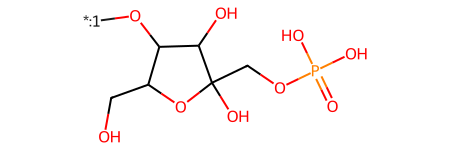

In [71]:
from rdkit import Chem
from rdkit.Chem import Draw, rdChemReactions
smiles = 'OCC1OC(C(O)C1OC)(O)COP(O)(O)=O'
smiles = 'OCC1OC(COP(O)(O)=O)(C(C1O[*:1])O)O'
mol = Chem.MolFromSmiles(smiles)
mol

*
C
N
C
C
N
C
C
*
O
*
O
*
O
O


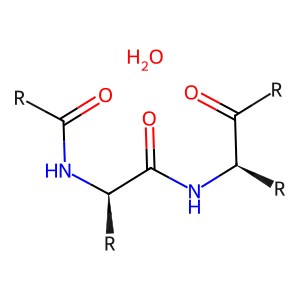

In [79]:
from rdkit import Chem
from rdkit.Chem import Draw

# Create a benzene with an R group placeholder (* atom)
mol = Chem.MolFromSmiles("[*:1]C(N[C@@H](C(N[C@@H](C([*:2])=O)[*:3])=O)[*:4])=O.O")

# Draw with atom labels
d2d = Draw.MolDraw2DSVG(300, 300)
opts = d2d.drawOptions()

# Replace '*' with "R1" in the rendering
for i, atom in enumerate(mol.GetAtoms()):
    print(atom.GetSymbol())
    if atom.GetSymbol() == "*":
        opts.atomLabels[i] = "R"

d2d.DrawMolecule(mol)
d2d.FinishDrawing()
svg = d2d.GetDrawingText()

# If in Jupyter/IPython you can do:
from IPython.display import SVG
SVG(svg)

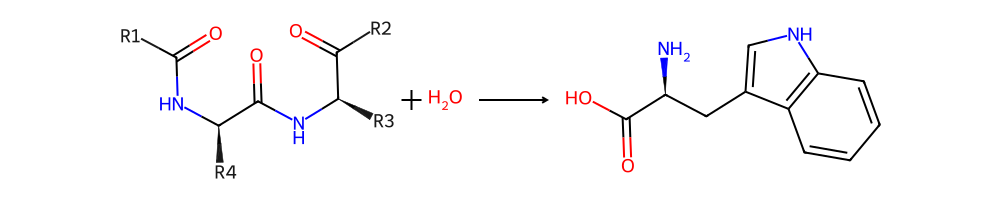

In [82]:
substrate_smiles = '[*]C(N[C@@H](C(N[C@@H](C([*])=O)[*])=O)[*])=O.O'
rxn_smarts = f"{substrate_smiles}>>{product_smiles}"
rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts, useSmiles=True)

# this function will return a raster image, and you can use
# this in dash with an html.Img(src=img)
# img = Draw.ReactionToImage(rxn)
# return img

# I am adding an adaptive height and width calculation here based on how internally rdkit
# is calculating its height and width. I am simply reversing its calculation.
# rdkit calculation is : width = subImgSize[0] * (rxn.GetNumReactantTemplates() + rxn.GetNumProductTemplates() + 1)
# ideally a final width of 1000 seems to be working well with the current layout.
# This number may need to change in the future
ideal_final_width = 1000
w = int(ideal_final_width / (rxn.GetNumReactantTemplates() + rxn.GetNumProductTemplates() + 1))
d2d = Draw.MolDraw2DSVG(1000, 200)
opts = d2d.drawOptions()

# Assign labels to dummy atoms (*) before drawing
r_counter = 1
for mol in list(rxn.GetReactants()) + list(rxn.GetProducts()):
    for atom in mol.GetAtoms():
        if atom.GetSymbol() == "*":
            atom.SetProp("atomLabel", f"R{r_counter}")
            atom.SetProp("molFileAlias", f"R{r_counter}")
            r_counter += 1
            
d2d.DrawReaction(rxn)
d2d.FinishDrawing()
svg = d2d.GetDrawingText()

# If in Jupyter/IPython you can do:
from IPython.display import SVG
SVG(svg)

In [67]:
opts

In [58]:
atom.GetSymbol()

'O'

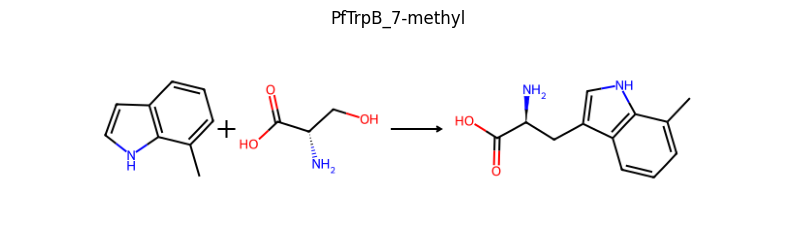

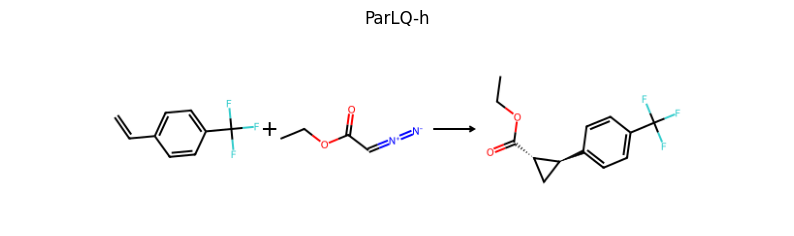

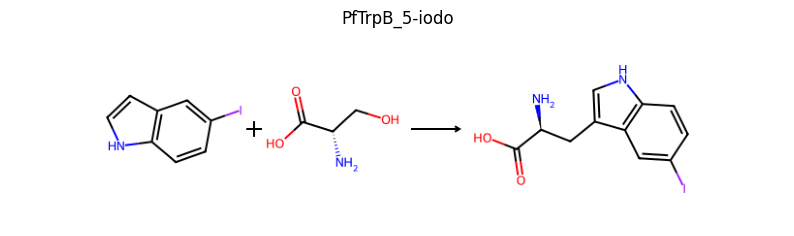

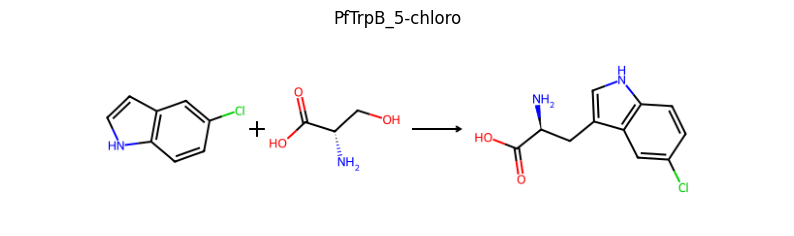

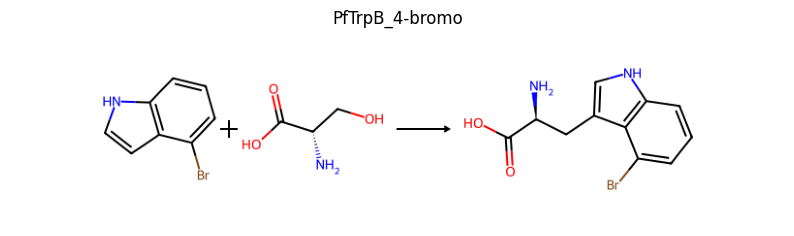

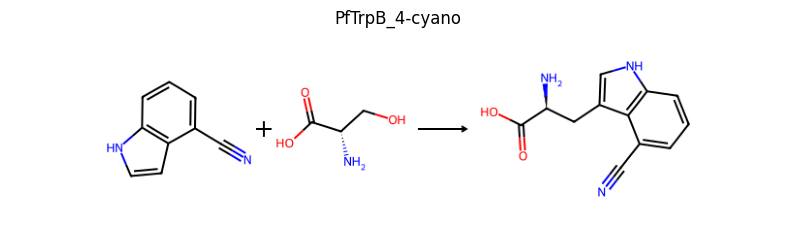

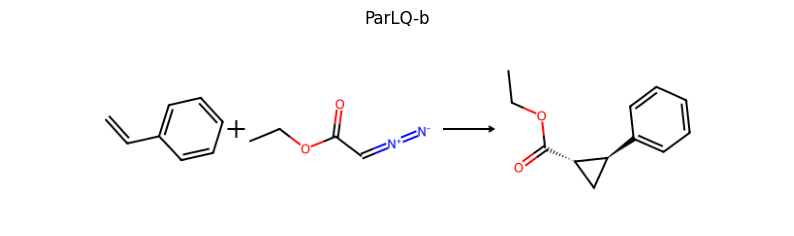

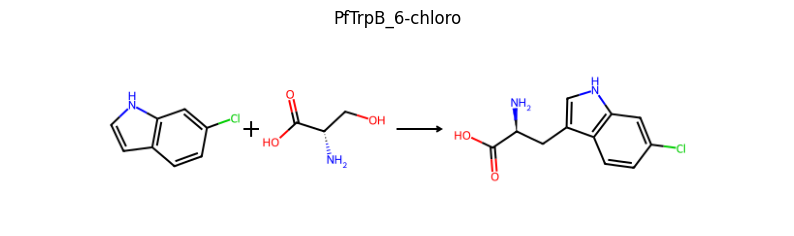

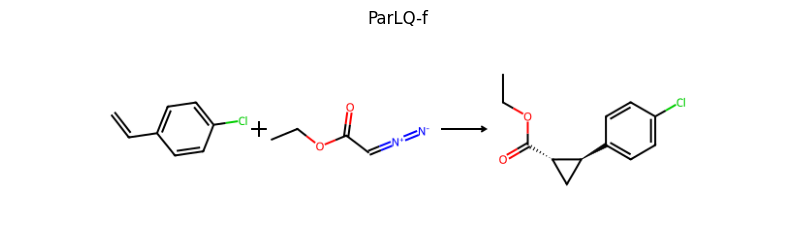

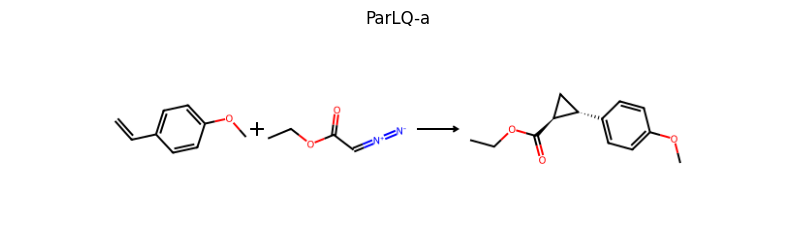

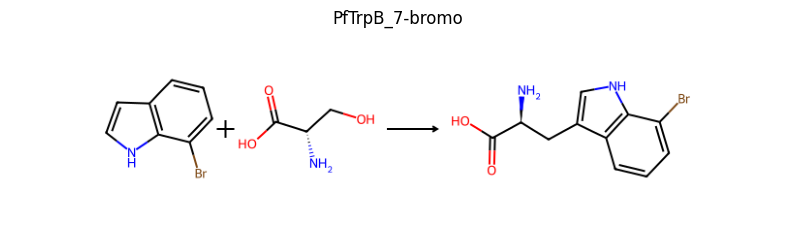

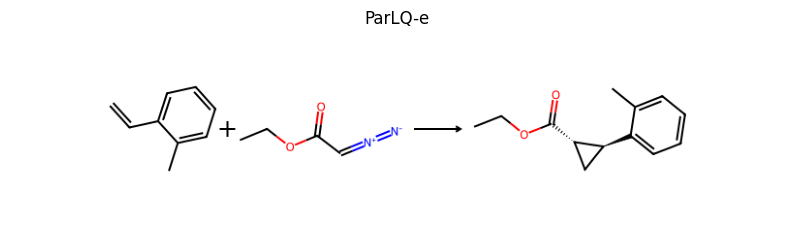

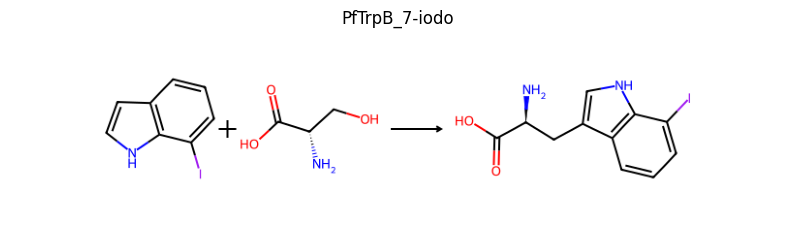

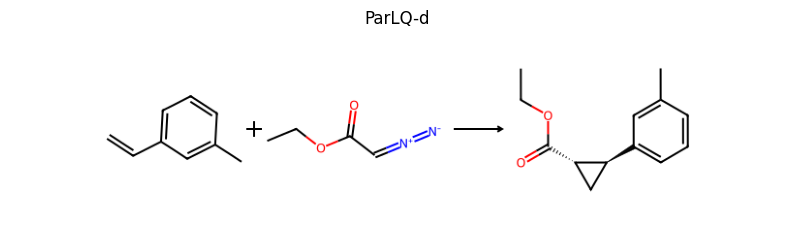

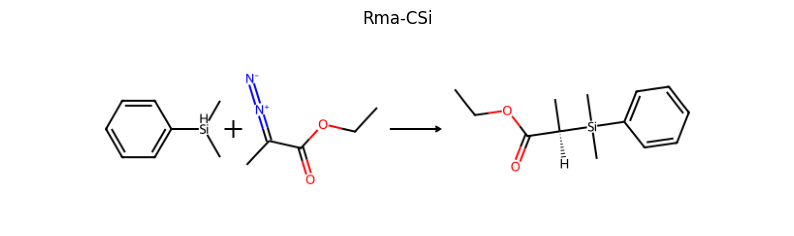

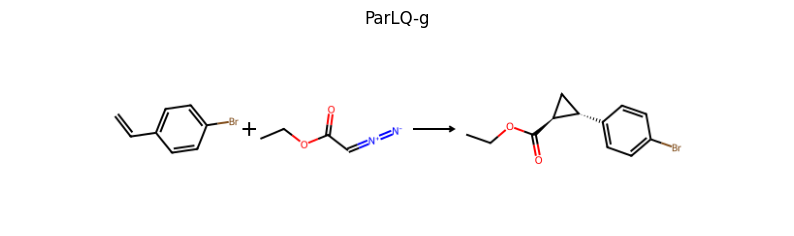

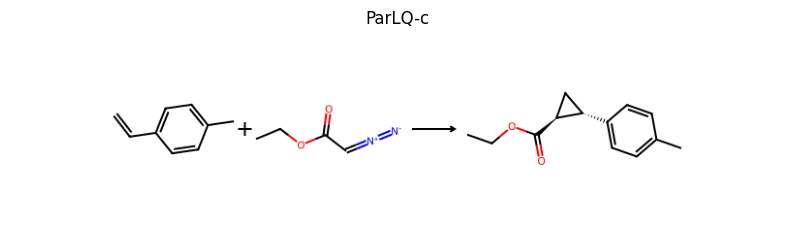

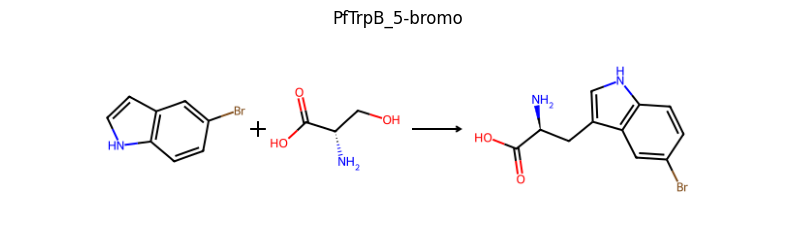

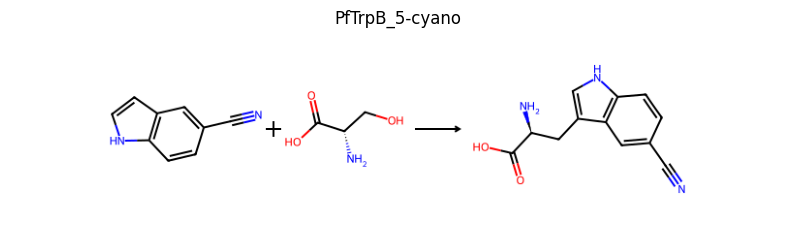

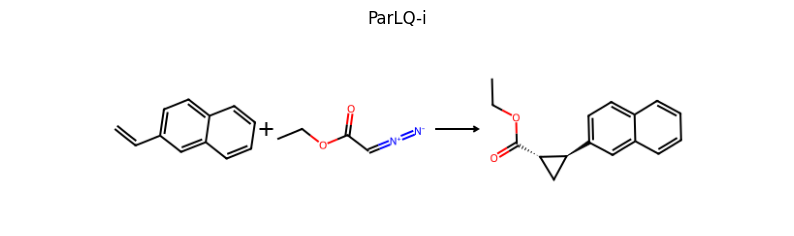

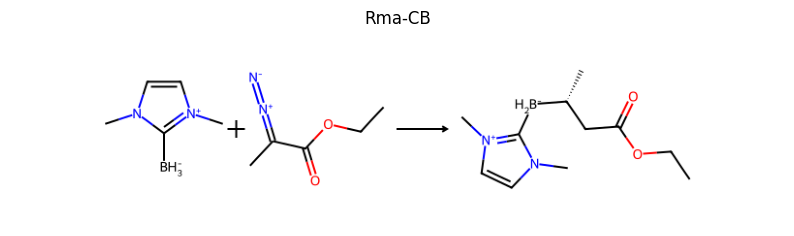

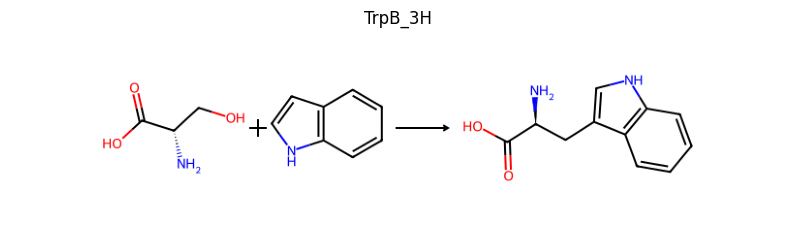

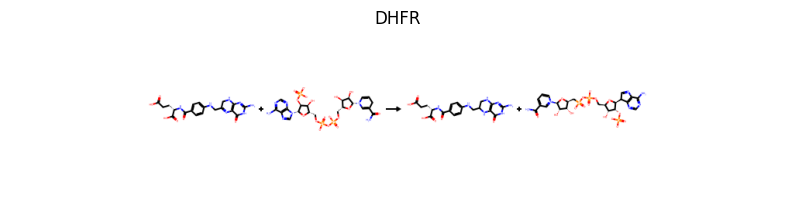

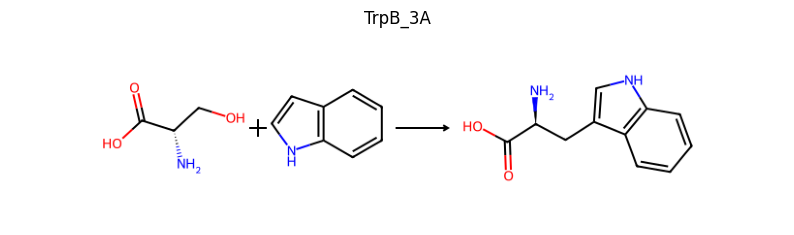

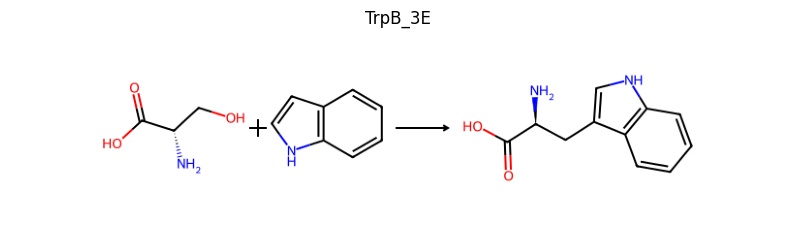

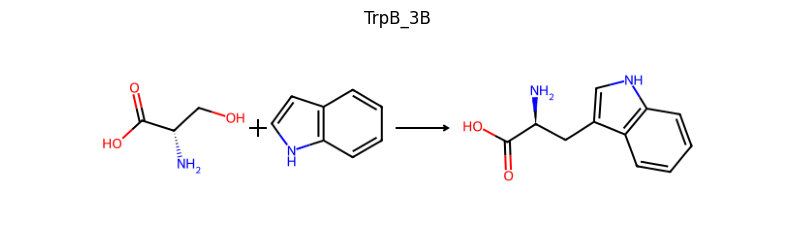

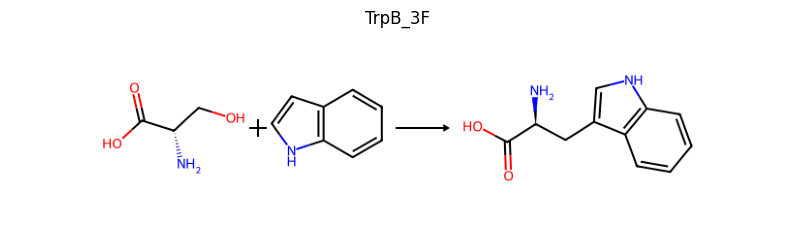

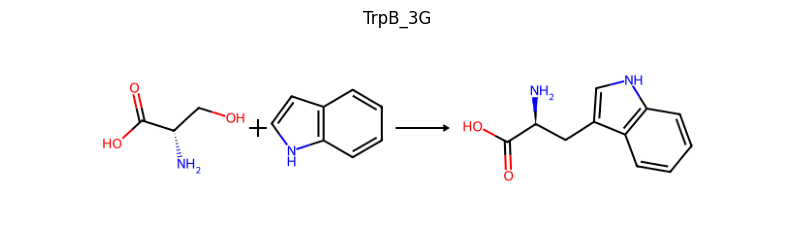

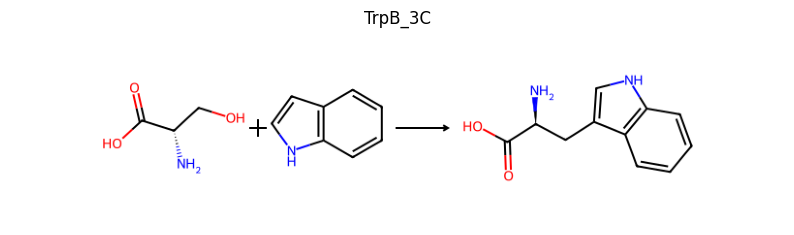

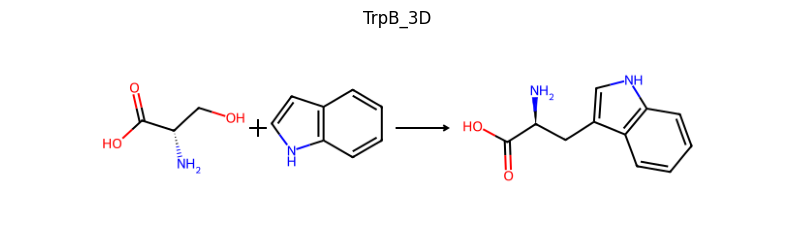

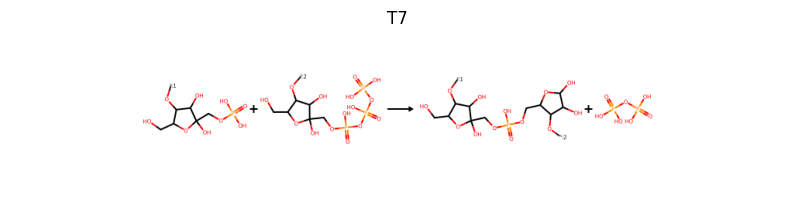

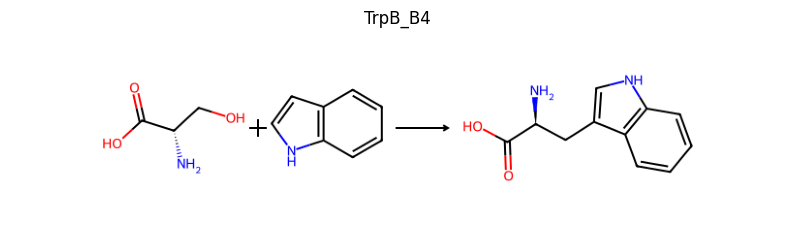

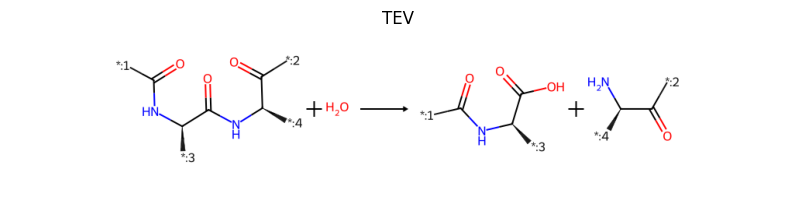

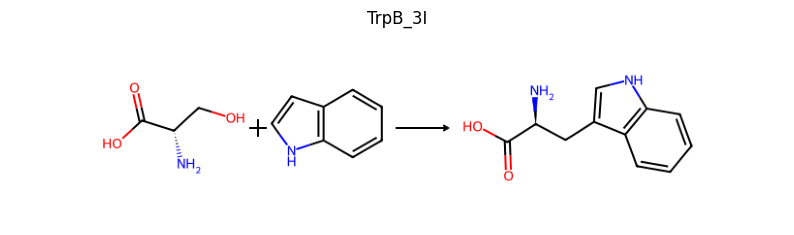

In [87]:
import matplotlib.pyplot as plt

for experiment_id, substrate_smiles, product_smiles in meta_df[['experiment_id', 'substrate_smiles', 'product_smiles']].values:
    rxn_smarts = f"{substrate_smiles}>>{product_smiles}"
    rxn = rdChemReactions.ReactionFromSmarts(rxn_smarts, useSmiles=True)
    print(rxn)
    ideal_final_width = 1000
    w = int(ideal_final_width / (rxn.GetNumReactantTemplates() + rxn.GetNumProductTemplates() + 1))
    
    # this option produces a svg image
    svg_img = Draw.ReactionToImage(rxn, subImgSize=(w, 200), useSVG=True)
    img = Draw.ReactionToImage(rxn)

    plt.figure(figsize=(10, 3))
    plt.title(experiment_id)
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [38]:
'OCC1OC(C(O)C1OC)(O)COP(O)(O)=O'

'OCC1OC(C(O)C1OC)(O)COP(O)(O)=O'

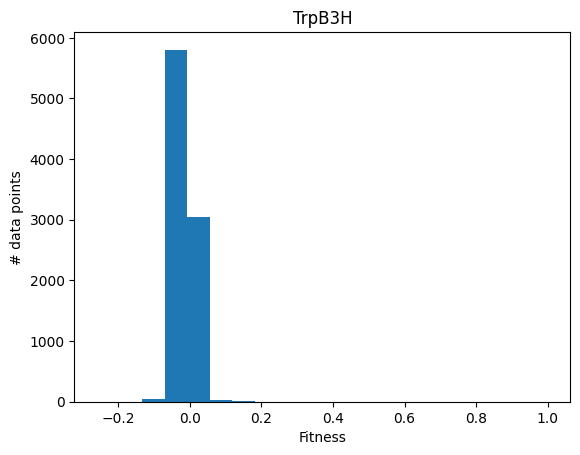

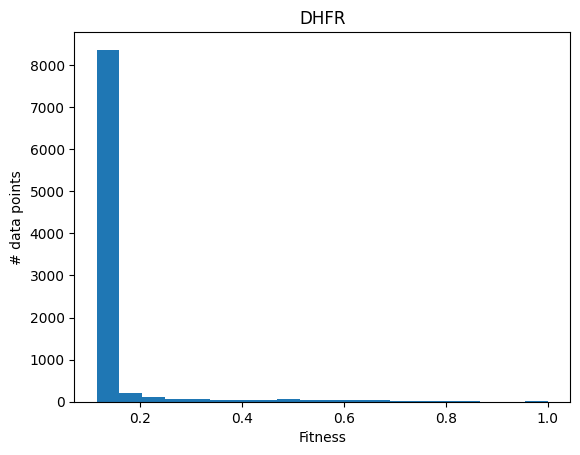

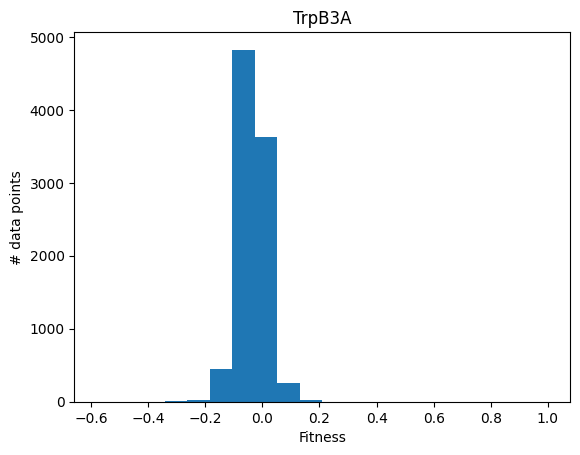

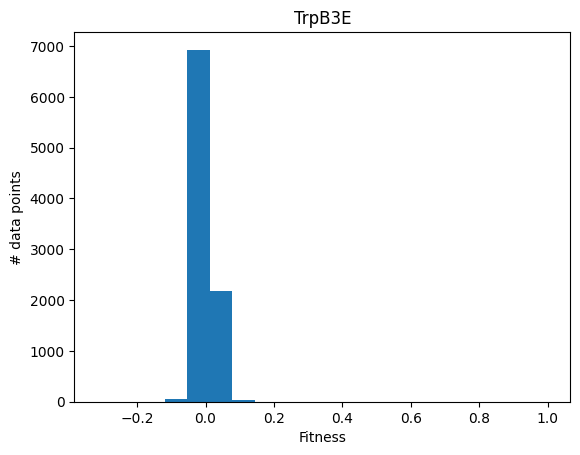

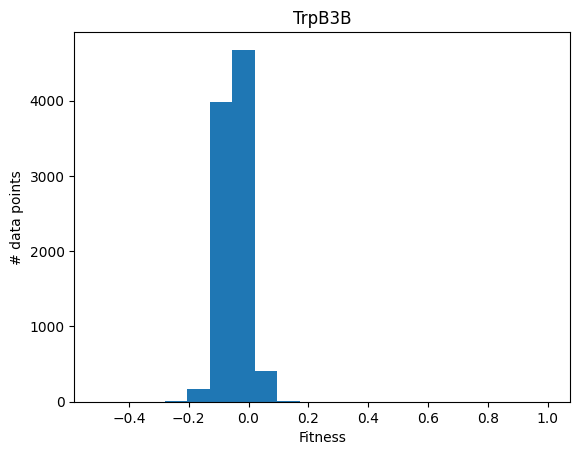

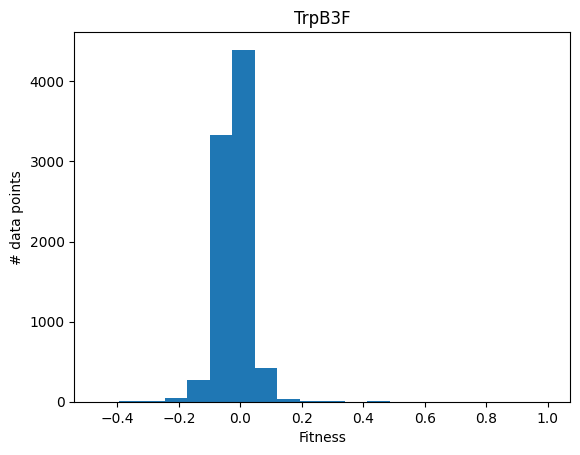

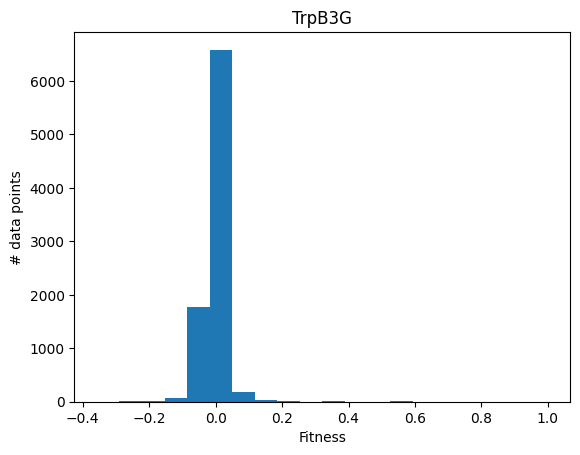

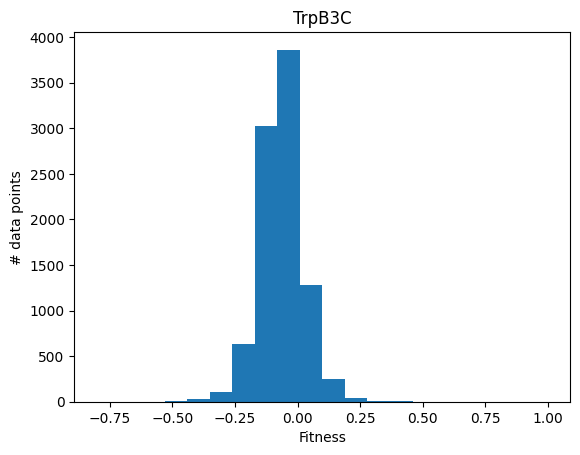

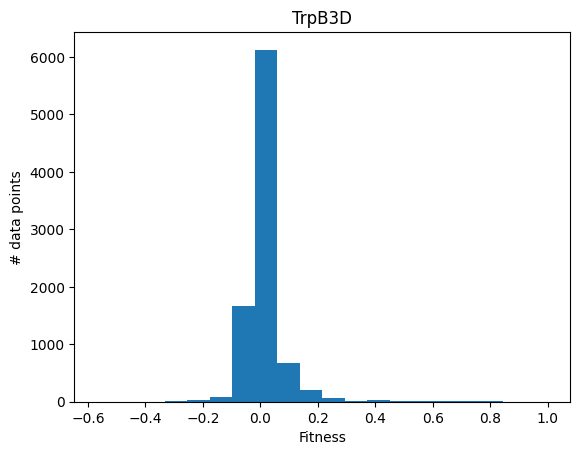

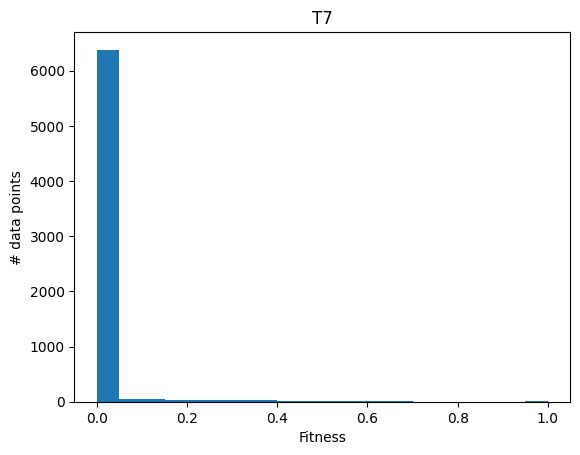

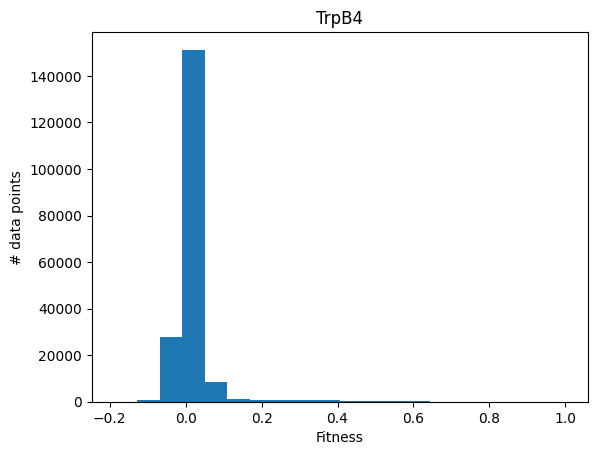

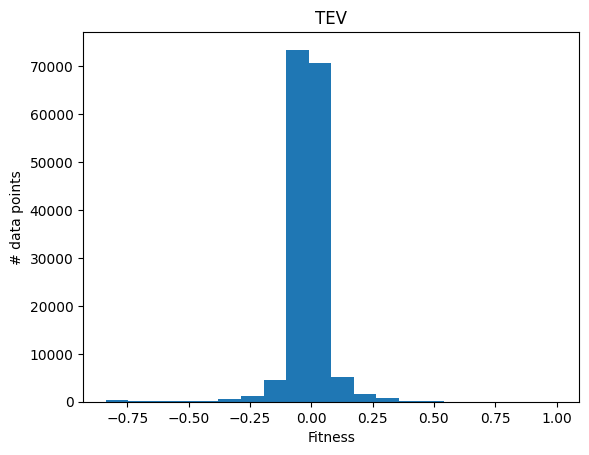

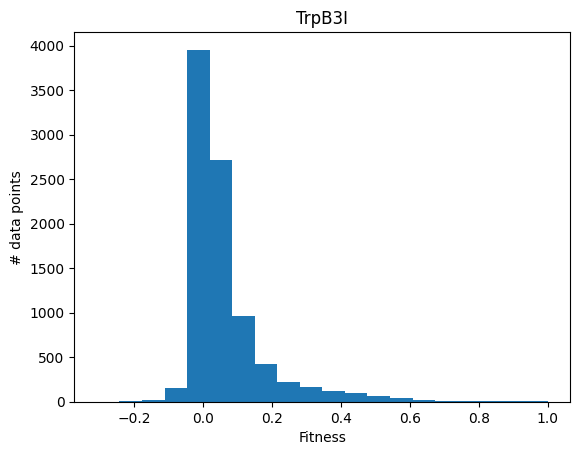

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

for f in files:
    try:
        df = pd.read_csv(f'{data_dir}{f}')
        plt.hist(df['fitness_value'].values, bins=20)
        plt.title(f.replace('_processed.csv', ''))
        plt.xlabel('Fitness')
        plt.ylabel('# data points')
        plt.show()
    except:
        print(f)
